<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_4_x_Exercise_Two_Parts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercises for 18_1 Parts 1 - 4

**The Premise:** You are a consulting Data Scientist tackling two consecutive projects for different clients.

*   **Client 1 (Finance):** A bank that needs a loan approval model. They care deeply about the *dollar cost* of mistakes.
*   **Client 2 (Public Health):** A social services agency predicting contraceptive method choice: No Use (0), Long-term (1), and Short-term (2). They need to identify potential long-term users to coordinate clinical logistics effectively.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report
)
from sklearn.utils import compute_sample_weight
from xgboost import XGBClassifier, plot_importance

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

---

## ACT I: The Binary Problem (Credit-g Dataset)
**Learning Focus:** Probabilities vs. Hard Predictions, ROC/PR Curves, Youden's J, and Business Cost-Curves.

### Step 1: The Baseline and the Accuracy Paradox

**Narrative:** The bank wants to predict "Bad Credit" (1) vs "Good Credit" (0). The data is naturally imbalanced (70% Good, 30% Bad).

Loading Credit-G dataset...


Baseline Accuracy: 72.50%


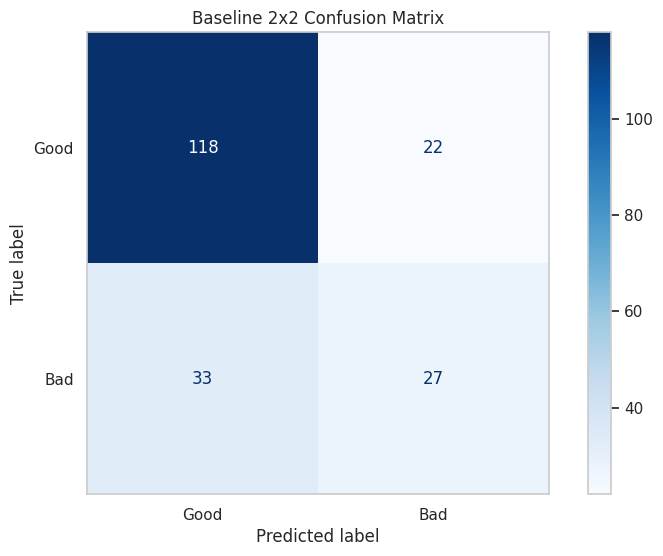

In [2]:
# 1. Load data
print("Loading Credit-G dataset...")
credit_data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = credit_data.data
y = credit_data.target.map({'good': 0, 'bad': 1})

# 2. Preprocess: Clean feature names and Encode
def clean_feature_names(df):
    df.columns = [
        col.replace(" ", "_")
        .replace("(", "").replace(")", "")
        .replace("[", "").replace("]", "")
        .replace("<", "lt")
        for col in df.columns
    ]
    return df

X = clean_feature_names(X)
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = clean_feature_names(X_encoded)

# 3. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Train Baseline
baseline_model = XGBClassifier(random_state=42, eval_metric='logloss')
baseline_model.fit(X_train, y_train)

# 5. Evaluate
y_pred = baseline_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {acc:.2%}")

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Good', 'Bad'], cmap='Blues'
)
plt.title("Baseline 2x2 Confusion Matrix")
plt.grid(False)
plt.show()

#### Problem 1
 This model has an accuracy of ~73%. What would the accuracy be if you wrote a one-line Python script that always predicted 'Good Credit'? Why is the bank's Chief Risk Officer unhappy with this model?

***
### Step 2: Peeking Under the Hood (Probabilities)

**Narrative:** Before tuning, we need to understand *how* the model is making its mistakes by looking at its confidence levels.

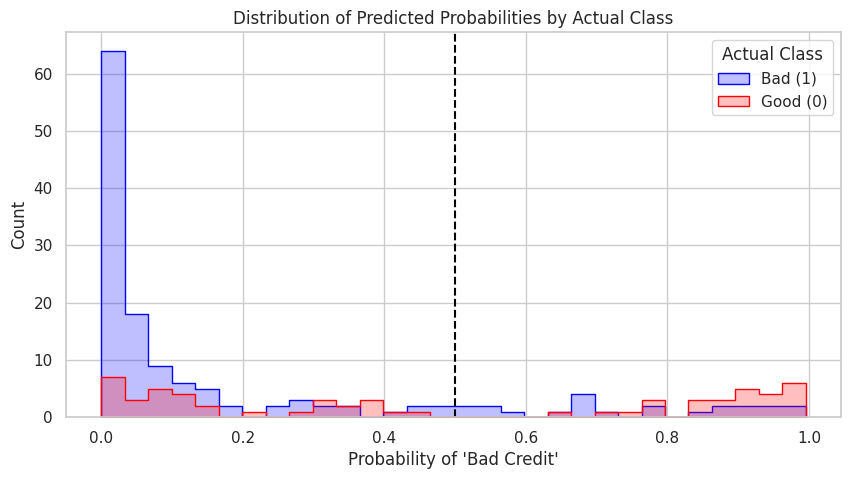

In [3]:
# Get probabilities for the positive class (Bad Credit)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 5))
sns.histplot(x=y_proba, hue=y_test, bins=30, element="step", palette={0: "blue", 1: "red"})
plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
plt.title("Distribution of Predicted Probabilities by Actual Class")
plt.xlabel("Probability of 'Bad Credit'")
plt.legend(title="Actual Class", labels=["Bad (1)", "Good (0)"])
plt.show()

#### Problem 2
Look at the overlapping area in the histogram. If we leave the threshold at 0.5, are we making more False Positives or False Negatives? What direction should we move the line to catch more 'Bad Credit' customers?

***
### Step 3: Tuning via Thresholds (ROC & Youden's J)

Let's find the mathematically optimal threshold using the ROC curve.

Mathematically Optimal Threshold (Youden's J): 0.0749


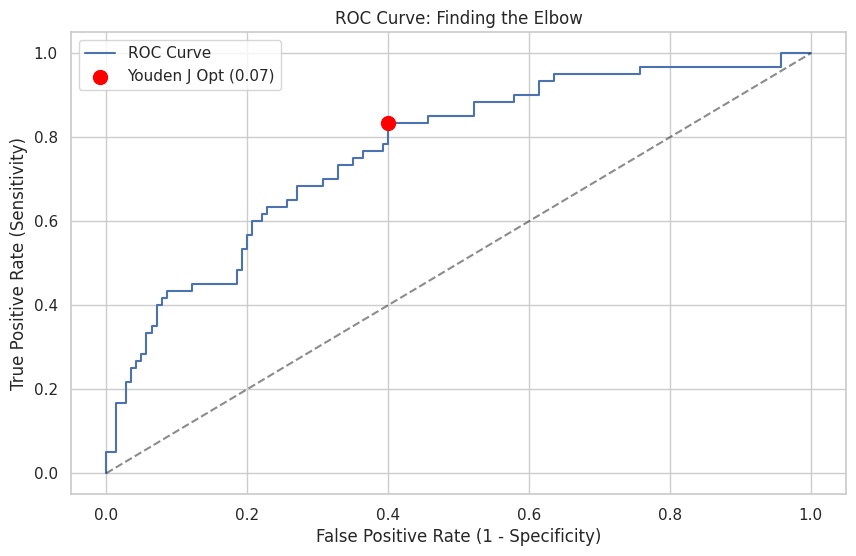

In [4]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calculate Youden's J (TPR - FPR)
youden_j = tpr - fpr
opt_idx = np.argmax(youden_j)
opt_threshold = thresholds[opt_idx]

print(f"Mathematically Optimal Threshold (Youden's J): {opt_threshold:.4f}")

plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=100, label=f'Youden J Opt ({opt_threshold:.2f})', zorder=5)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title("ROC Curve: Finding the Elbow")
plt.legend()
plt.show()

#### Problem 3
Youden's J suggests a lower threshold. Use the code block below to apply this threshold. How did the TP, TN, FP, and FN numbers shift compared to Step 1?

In [5]:
# TODO: Apply the opt_threshold to y_proba to get new predictions
y_pred_tuned = (y_proba >= opt_threshold).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Tuned Confusion Matrix:")
print(cm_tuned)

Tuned Confusion Matrix:
[[84 56]
 [10 50]]


***
### Step 4: The Business Cost Curve

The bank says approving a bad loan (False Positive) costs the bank 5,000 on average. Rejecting a good loan (False Negative) costs the bank $1,000 in lost revenue on average.

Business-Optimal Threshold: 0.9842


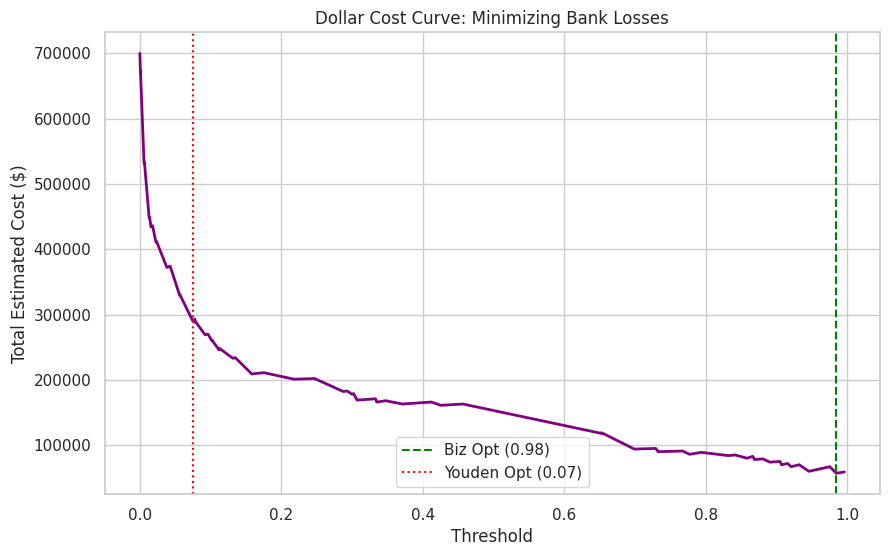

In [6]:
# Here we set the costs
COST_FP = 5000
COST_FN = 1000

def calculate_total_cost(y_true, y_probs, threshold):
    preds = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return (fp * COST_FP) + (fn * COST_FN)

# Use the actual thresholds from our ROC curve for precision
valid_thresholds = thresholds[(thresholds >= 0) & (thresholds <= 1)]
costs = [calculate_total_cost(y_test, y_proba, t) for t in valid_thresholds]

biz_opt_threshold = valid_thresholds[np.argmin(costs)]
print(f"Business-Optimal Threshold: {biz_opt_threshold:.4f}")

plt.plot(valid_thresholds, costs, color='purple', lw=2)
plt.axvline(biz_opt_threshold, color='green', linestyle='--', label=f'Biz Opt ({biz_opt_threshold:.2f})')
plt.axvline(opt_threshold, color='red', linestyle=':', label=f'Youden Opt ({opt_threshold:.2f})')
plt.title("Dollar Cost Curve: Minimizing Bank Losses")
plt.xlabel("Threshold")
plt.ylabel("Total Estimated Cost ($)")
plt.legend()
plt.show()

#### Problem 4 ####
Did the business-optimal threshold match Youden's J? Why or why not? Write a 2-sentence recommendation to the bank on where to set their system.

---

## ACT II: The Multiclass Problem (Contraceptive Method Choice Dataset)
**Learning Focus:** The 3x3 Matrix, Macro vs Weighted F1, and `sample_weights`.

### Step 5: Transitioning to Multiclass (The Trap)

**Narrative:** Social services data for contraceptive choice: No Use (0), Long-term (1), Short-term (2). Imbalance: ~43% / ~23% / ~35%.

In [7]:
print("Loading Contraceptive Method Choice dataset...")
cmc = fetch_openml(data_id=23, as_frame=True, parser='auto')
X_c = cmc.data
y_c = cmc.target.astype(int) - 1 # Map 1,2,3 to 0,1,2

# Clean names for XGBoost
X_c = clean_feature_names(X_c)
X_c_encoded = pd.get_dummies(X_c, drop_first=True)
X_c_encoded = clean_feature_names(X_c_encoded)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c_encoded, y_c, test_size=0.2, random_state=42, stratify=y_c
)

baseline_multi = XGBClassifier(random_state=42, objective='multi:softprob')
baseline_multi.fit(X_train_c, y_train_c)

y_pred_c = baseline_multi.predict(X_test_c)
print(classification_report(y_test_c,
                            y_pred_c,
                            target_names=['No Use', 'Long-term', 'Short-term']))

Loading Contraceptive Method Choice dataset...


              precision    recall  f1-score   support

      No Use       0.60      0.62      0.61       126
   Long-term       0.42      0.33      0.37        67
  Short-term       0.45      0.49      0.47       102

    accuracy                           0.51       295
   macro avg       0.49      0.48      0.48       295
weighted avg       0.50      0.51      0.51       295



#### Problem 5
Why is the 'Weighted Avg F1' score so much higher than the 'Macro Avg F1'? If you were working for the agency caring about the rare 'Long-term' cases, which metric would you trust?



***
### Step 6: Forcing Fairness with Sample Weights

**Narrative:** We must force the model to treat each class as equally important, regardless of how many examples exist.

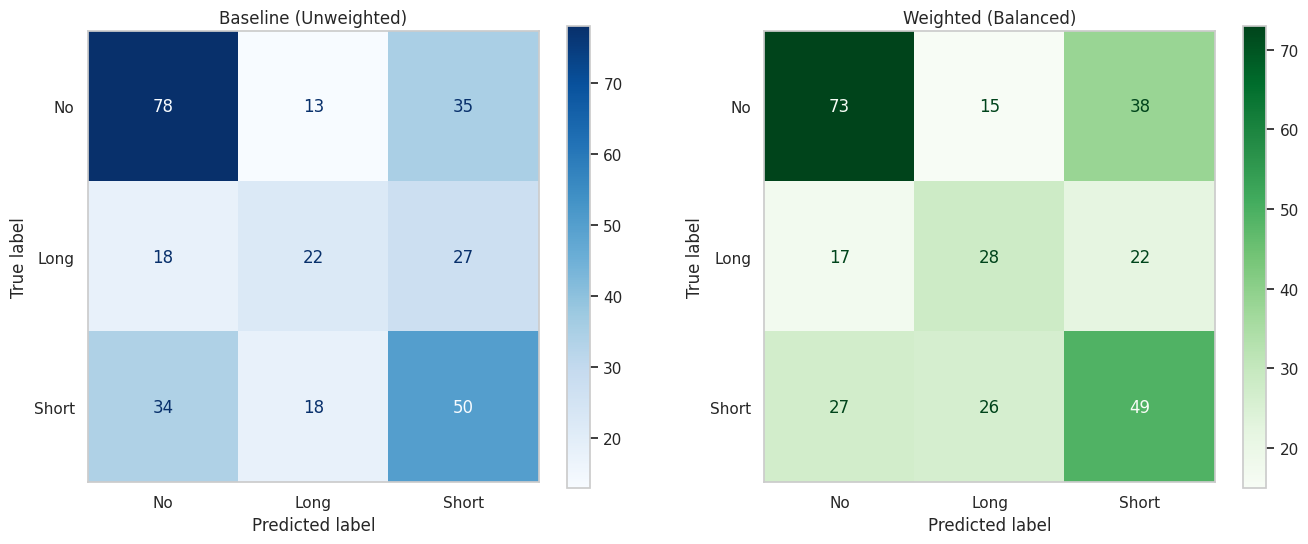

In [8]:
# TODO: Calculate balanced sample weights for the training set
weights = compute_sample_weight(class_weight='balanced', y=y_train_c)

weighted_multi = XGBClassifier(random_state=42, objective='multi:softprob')
weighted_multi.fit(X_train_c, y_train_c, sample_weight=weights)

y_pred_w = weighted_multi.predict(X_test_c)

# Visual comparison: Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_c, display_labels=['No', 'Long', 'Short'], cmap='Blues', ax=ax1
)
ax1.set_title("Baseline (Unweighted)")
ax1.grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_w, display_labels=['No', 'Long', 'Short'], cmap='Greens', ax=ax2
)
ax2.set_title("Weighted (Balanced)")
ax2.grid(False)

plt.show()

**Student Reflection:** By adding sample weights, our overall accuracy might drop. However, look at the middle cell (Actual Long-term, Predicted Long-term). Explain why the agency will prefer this 'lower accuracy' model using the terms 'False Alarm' (Predicting Long-term when No Use) and 'Logistical Miss' (Predicting No Use when Long-term).

***
### Step 7: Interpreting the Black Box

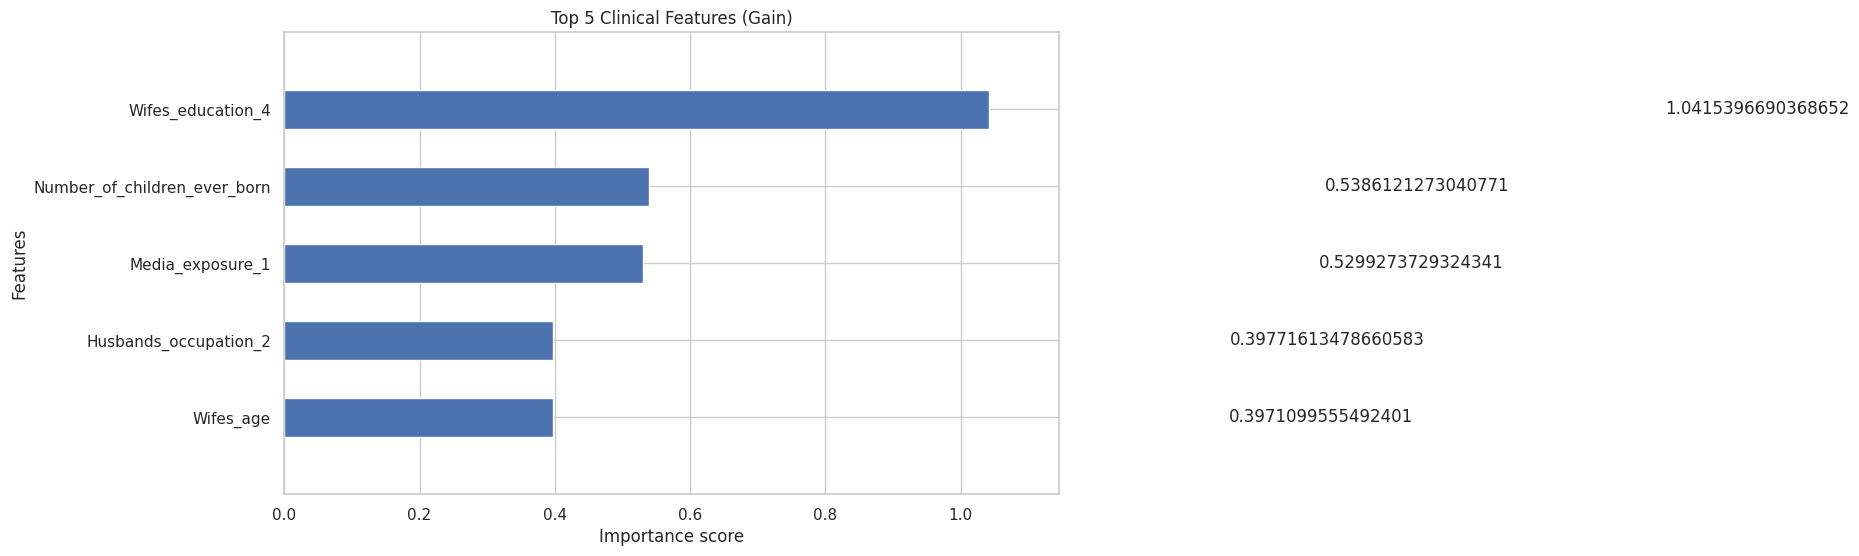

In [9]:
plot_importance(weighted_multi, importance_type='gain', max_num_features=5, height=0.5)
plt.title("Top 5 Clinical Features (Gain)")
plt.show()

**Student Reflection:** List the top 3 features by Gain. How might you explain the limitation of this chart to an agency director who asks, 'Does a higher education level mean the person is more likely to use long-term contraception?'

---
## Summary Checklist
1. [ ] Identified the Accuracy Paradox.
2. [ ] Found Youden's J optimal threshold.
3. [ ] Minimized Business Costs via the Cost Curve.
4. [ ] Compared Macro vs. Weighted F1 for multiclass.
5. [ ] Used Sample Weights to fix minority class neglect.